In [1]:
import glob
from pathlib import Path
import pandas as pd

from modeling.Modeling import Modeling
from utility.Point2d import Point2d

GT_PATH = "D:/Programacao/mAP/input/ground-truth"
DIST_THRESHOLD = 100

modeling = Modeling()
models = glob.glob("perception/darknet/models/*.pt")
all_info = pd.DataFrame(columns=["model", "name", "confidence", "error_x1", "error_x2"])
for model in models:
    model_name = Path(model).stem
    result_folder = "perception/test_results/" + model_name
    detection_files = glob.glob(result_folder + "/*.txt")
    gt_files = glob.glob(GT_PATH + "/*.txt")
    assert set([Path(f).name for f in detection_files]) == set([Path(f).name for f in gt_files])
    detection_files = sorted(detection_files, key=lambda x : Path(x).name)
    gt_files = sorted(gt_files, key=lambda x : Path(x).name)
    for detection_file, gt_file in zip(detection_files, gt_files):
        detections_df = pd.DataFrame(columns=["name", "confidence", "x1", "x2"])
        gt_df = pd.DataFrame(columns=["name", "x1", "x2"])
        with open(detection_file, "r") as detection:
            with open(gt_file, "r") as gt:
                detection_lines = detection.readlines()
                gt_lines = gt.readlines()
                temp_list = []
                for detection_line in detection_lines:
                    name, conf, x1, y1, x2, y2 = detection_line.split(" ")
                    conf = float(conf)
                    x1 = float(x1)
                    x2 = float(x2)
                    y1 = float(y1)
                    y2 = float(y2)
                    screen_point = Point2d((x1+x2)/2, y2)
                    temp_list.append({
                        "name": name,
                        "confidence": conf,
                        "x1": screen_point.x1,
                        "x2": screen_point.x2,
                    })
                detections_df = pd.concat([detections_df, pd.DataFrame(temp_list)], ignore_index=True)

                temp_list = []
                for gt_line in gt_lines:
                    name, x1, y1, x2, y2 = gt_line.split(" ")
                    x1 = float(x1)
                    x2 = float(x2)
                    y1 = float(y1)
                    y2 = float(y2)
                    screen_point = Point2d((x1+x2)/2, y2)
                    temp_list.append({
                        "name": name,
                        "x1": screen_point.x1,
                        "x2": screen_point.x2,
                    })
                gt_df = pd.concat([gt_df, pd.DataFrame(temp_list)], ignore_index=True)

                temp_list = []
                for index, row in detections_df.iterrows():
                    name = row["name"]
                    confidence = row["confidence"]
                    detection_x1 = row["x1"]
                    detection_x2 = row["x2"]
                    closest = None
                    closest_dist = None
                    for gt_index, gt_row in gt_df.iterrows():
                        gt_name = gt_row["name"]
                        if gt_name != name:
                            continue
                        gt_x1 = gt_row["x1"]
                        gt_x2 = gt_row["x2"]
                        dist = Point2d(detection_x1, detection_x2).distance(Point2d(gt_x1, gt_x2))
                        if closest is None or closest_dist > dist:
                            closest = Point2d(gt_x1, gt_x2)
                            closest_dist = dist

                    if closest is None or closest_dist > DIST_THRESHOLD:
                        continue
                        
                    error_x1 = closest.x1 - detection_x1
                    error_x2 = closest.x2 - detection_x2
                    temp_list.append({
                        "model": model_name,
                        "name": name,
                        "confidence": confidence,
                        "error_x1": error_x1,
                        "error_x2": error_x2,
                    })
                all_info = pd.concat([all_info, pd.DataFrame(temp_list)], ignore_index=True)



In [2]:
all_info.to_csv("estimation_errors/yolo_data.csv", index=False)

In [3]:
all_info = pd.read_csv("estimation_errors/yolo_data.csv")

In [4]:
all_info["error_x1"].describe()

count    22586.000000
mean         0.677986
std          5.604422
min        -77.000000
25%         -0.500000
50%          0.500000
75%          2.000000
max         98.000000
Name: error_x1, dtype: float64

In [5]:
all_info["error_x2"].describe()

count    22586.000000
mean         2.369477
std          6.789324
min        -97.000000
25%          0.000000
50%          2.000000
75%          4.000000
max         96.000000
Name: error_x2, dtype: float64

<AxesSubplot:>

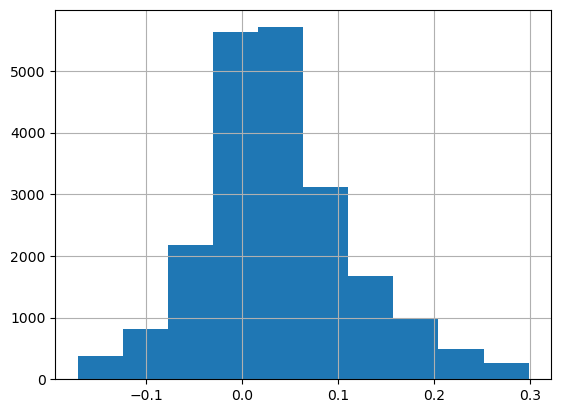

In [6]:
q_low = all_info["error_x1"].quantile(0.03)
q_high = all_info["error_x1"].quantile(0.97)

all_info["error_x1"][(all_info["error_x1"] > q_low) & (all_info["error_x1"] < q_high)].hist()

<AxesSubplot:>

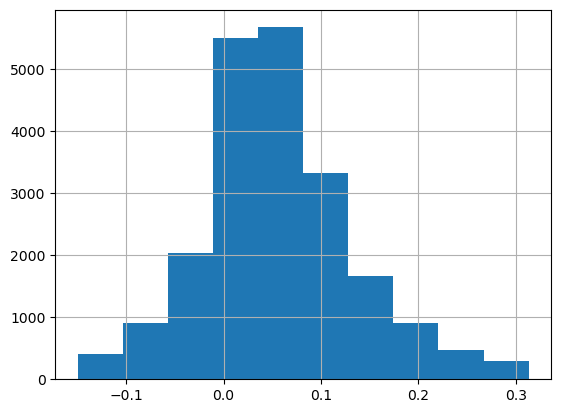

In [7]:
q_low = all_info["error_x2"].quantile(0.03)
q_high = all_info["error_x2"].quantile(0.97)

all_info["error_x2"][(all_info["error_x2"] > q_low) & (all_info["error_x2"] < q_high)].hist()

In [6]:
cond1 = (all_info["error_x1"] > all_info["error_x1"].quantile(0.03)) & (all_info["error_x1"] < all_info["error_x1"].quantile(0.97))
cond2 = (all_info["error_x2"] > all_info["error_x2"].quantile(0.03)) & (all_info["error_x2"] < all_info["error_x2"].quantile(0.97))
all_info[["error_x1", "error_x2"]][cond1 & cond2].cov()

,error_x1,error_x2
error_x1,3.836410,0.138089
error_x2,0.138089,8.891213


In [23]:
all_info["error_x1"][cond1 & cond2].std()

1.9586754719414754

In [24]:
all_info["error_x2"][cond1 & cond2].std()

2.9818136496160217